In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
df = pd.read_csv("Flight_Analysis.csv")

df


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,...,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,NK,597,MSP,FLL,115,127,...,1487,542,25,0,0,25,0,0,0,0
1,2015,1,1,4,NK,168,PHX,ORD,125,237,...,1440,549,43,0,0,43,0,0,0,0
2,2015,1,1,4,HA,17,LAS,HNL,145,145,...,2762,555,15,0,0,0,0,15,0,0
3,2015,1,1,4,B6,1030,BQN,MCO,307,304,...,1129,500,20,0,0,20,0,0,0,0
4,2015,1,1,4,B6,2134,SJU,MCO,400,535,...,1189,605,85,0,0,0,0,85,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90250,2015,1,29,4,MQ,3101,OKC,ORD,1531,1536,...,693,1733,53,0,0,53,0,0,0,0
90251,2015,1,29,4,OO,4559,DTW,SBN,1532,1526,...,157,1634,20,0,0,20,0,0,0,0
90252,2015,1,29,4,EV,5604,DTW,AVP,1534,1531,...,399,1652,28,0,0,28,0,0,0,0
90253,2015,1,29,4,UA,1733,SFO,DEN,1534,1545,...,967,1903,20,0,0,9,0,11,0,0


In [4]:
df.shape

(90255, 23)

In [5]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,...,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,NK,597,MSP,FLL,115,127,...,1487,542,25,0,0,25,0,0,0,0
1,2015,1,1,4,NK,168,PHX,ORD,125,237,...,1440,549,43,0,0,43,0,0,0,0
2,2015,1,1,4,HA,17,LAS,HNL,145,145,...,2762,555,15,0,0,0,0,15,0,0
3,2015,1,1,4,B6,1030,BQN,MCO,307,304,...,1129,500,20,0,0,20,0,0,0,0
4,2015,1,1,4,B6,2134,SJU,MCO,400,535,...,1189,605,85,0,0,0,0,85,0,0


**Which airline has the highest average arrival delay?**


In [6]:
df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] >= 15).astype(int)

In [7]:
df["ARRIVAL_DELAY"].groupby(df["AIRLINE"]).mean().sort_values(
    ascending=False
)

AIRLINE
F9    69.455882
OO    64.283974
MQ    63.614752
EV    60.621949
NK    60.491870
AA    58.505884
UA    58.259960
B6    57.119796
DL    55.997138
VX    54.698435
AS    49.919976
WN    47.817325
US    46.890846
HA    39.412579
Name: ARRIVAL_DELAY, dtype: float64

In [8]:
airline_analysis = df.groupby("AIRLINE").agg(
    Total_Flights=("AIRLINE", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
).sort_values(
    "Average_Delay",
    ascending=False
)

print(airline_analysis)

         Total_Flights  Average_Delay
AIRLINE                              
F9                2040      69.455882
OO               10751      64.283974
MQ                9124      63.614752
EV               10488      60.621949
NK                2214      60.491870
AA                9093      58.505884
UA                7932      58.259960
B6                4516      57.119796
DL                7686      55.997138
VX                 703      54.698435
AS                1687      49.919976
WN               17720      47.817325
US                5506      46.890846
HA                 795      39.412579


In [9]:
df.groupby("AIRLINE")["ARRIVAL_DELAY"].agg(
    ["count", "mean", "median", "max"]
).sort_values("mean", ascending=False)

,count,mean,median,max
AIRLINE,,,,
F9,2040,69.455882,41.0,686
OO,10751,64.283974,42.0,916
MQ,9124,63.614752,44.0,788
EV,10488,60.621949,38.0,723
NK,2214,60.491870,40.0,570
AA,9093,58.505884,36.0,1971
UA,7932,58.259960,37.0,863
B6,4516,57.119796,40.0,502
DL,7686,55.997138,33.0,1174


In [10]:
df["ARRIVAL_DELAY"].min()

np.int64(15)

In [11]:
airline_analysis = df.groupby("AIRLINE").agg(
    Total_Flights=("AIRLINE", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
).sort_values("Average_Delay", ascending=False)

airline_analysis

,Total_Flights,Average_Delay
AIRLINE,,
F9,2040,69.455882
OO,10751,64.283974
MQ,9124,63.614752
EV,10488,60.621949
NK,2214,60.491870
AA,9093,58.505884
UA,7932,58.259960
B6,4516,57.119796
DL,7686,55.997138


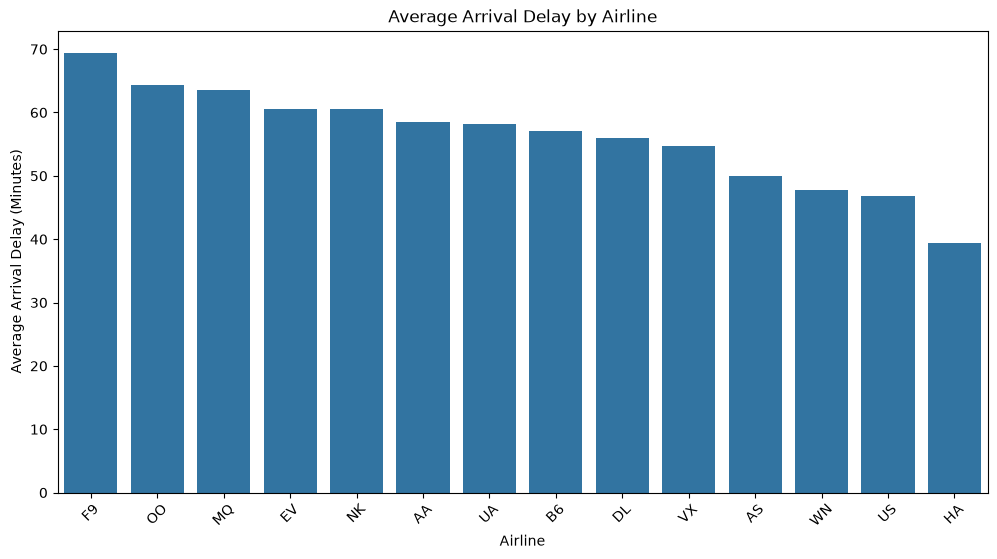

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=airline_analysis.index,
    y=airline_analysis["Average_Delay"]
)

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=45)

plt.show()

***2. Which month has higher delays?***

In [13]:
df["MONTH"].unique()

array([1])

In [14]:
df["MONTH"].value_counts().sort_index()

MONTH
1    90255
Name: count, dtype: int64

In [15]:
monthly_analysis = (
    df.groupby("MONTH")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
)

print(monthly_analysis)

MONTH
1    56.782716
Name: ARRIVAL_DELAY, dtype: float64


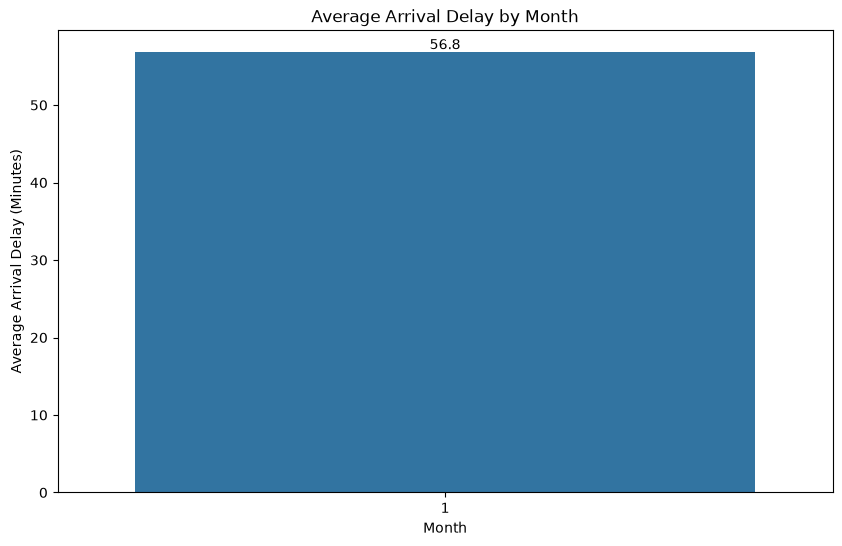

In [16]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=monthly_analysis.index,
    y=monthly_analysis.values
)

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (Minutes)")

# Show values
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

***3. Which airport has higher delay rate?***

In [17]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,...,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED
0,2015,1,1,4,NK,597,MSP,FLL,115,127,...,542,25,0,0,25,0,0,0,0,1
1,2015,1,1,4,NK,168,PHX,ORD,125,237,...,549,43,0,0,43,0,0,0,0,1
2,2015,1,1,4,HA,17,LAS,HNL,145,145,...,555,15,0,0,0,0,15,0,0,1
3,2015,1,1,4,B6,1030,BQN,MCO,307,304,...,500,20,0,0,20,0,0,0,0,1
4,2015,1,1,4,B6,2134,SJU,MCO,400,535,...,605,85,0,0,0,0,85,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90250,2015,1,29,4,MQ,3101,OKC,ORD,1531,1536,...,1733,53,0,0,53,0,0,0,0,1
90251,2015,1,29,4,OO,4559,DTW,SBN,1532,1526,...,1634,20,0,0,20,0,0,0,0,1
90252,2015,1,29,4,EV,5604,DTW,AVP,1534,1531,...,1652,28,0,0,28,0,0,0,0,1
90253,2015,1,29,4,UA,1733,SFO,DEN,1534,1545,...,1903,20,0,0,9,0,11,0,0,1


In [18]:
airport_analysis = df.groupby("ORIGIN_AIRPORT").agg(
    Total_Flights=("ORIGIN_AIRPORT", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
).sort_values("Average_Delay", ascending=False)

print(airport_analysis.head(10))

                Total_Flights  Average_Delay
ORIGIN_AIRPORT                              
PIH                         9     213.555556
ABR                         9     186.888889
ESC                         7     164.000000
VEL                         5     138.000000
EAU                        13     124.307692
PAH                         7     119.571429
IMT                         8     109.250000
APN                        12     102.583333
TVC                        50     101.900000
HOB                         3     101.000000


In [19]:
airport_analysis_100 = airport_analysis[
    airport_analysis["Total_Flights"] >= 100
].sort_values("Average_Delay", ascending=False)

print(airport_analysis_100.head(10))

                Total_Flights  Average_Delay
ORIGIN_AIRPORT                              
COS                       144      94.041667
ROC                       110      87.272727
CAE                       106      83.066038
ICT                       125      82.608000
RIC                       244      78.663934
FSD                       142      78.246479
FAT                       174      74.988506
JAC                       102      74.519608
OMA                       254      74.405512
GEG                       123      74.292683


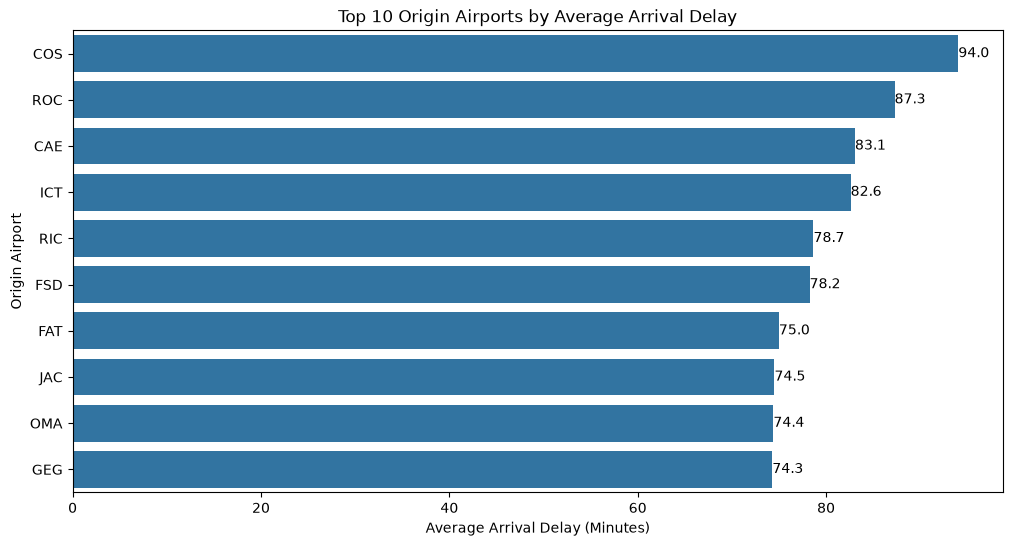

In [20]:
top_airports = airport_analysis_100.head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_airports["Average_Delay"],
    y=top_airports.index
)

plt.title("Top 10 Origin Airports by Average Arrival Delay")
plt.xlabel("Average Arrival Delay (Minutes)")
plt.ylabel("Origin Airport")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

***4. Which day has higher delays?***

In [21]:
day_analysis = df.groupby("DAY_OF_WEEK").agg(
    Total_Flights=("DAY_OF_WEEK", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
).sort_values("Average_Delay", ascending=False)

print(day_analysis)

             Total_Flights  Average_Delay
DAY_OF_WEEK                              
7                    15502      61.910463
2                    10898      58.583318
1                    15400      58.196883
6                    11565      56.588759
4                    13017      55.382269
3                    10376      53.523805
5                    13497      51.847966


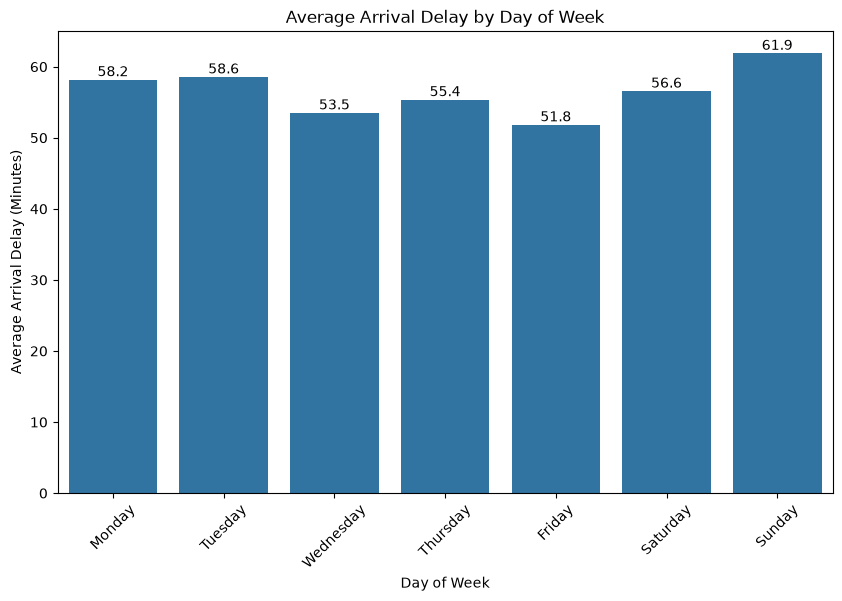

In [22]:
day_analysis = day_analysis.sort_index()

day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_analysis.index = day_analysis.index.map(day_names)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=day_analysis.index,
    y=day_analysis["Average_Delay"]
)

plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

***5. How are delays distributed?***

In [23]:
df["ARRIVAL_DELAY"].describe()

count    90255.000000
mean        56.782716
std         60.709670
min         15.000000
25%         23.000000
50%         37.000000
75%         68.000000
max       1971.000000
Name: ARRIVAL_DELAY, dtype: float64

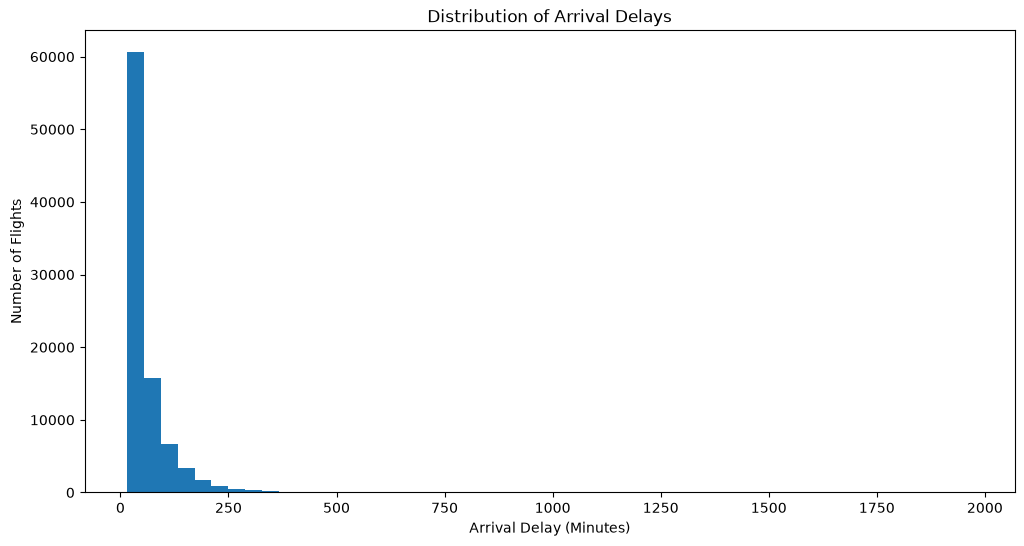

In [24]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["ARRIVAL_DELAY"],
    bins=50
)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

In [25]:
df["DELAY_CATEGORY"] = pd.cut(
    df["ARRIVAL_DELAY"],
    bins=[15, 30, 60, 120, float("inf")],
    labels=[
        "15-30 min",
        "31-60 min",
        "61-120 min",
        "120+ min"
    ],
    include_lowest=True
)

delay_distribution = df["DELAY_CATEGORY"].value_counts().sort_index()

print(delay_distribution)

DELAY_CATEGORY
15-30 min     36787
31-60 min     27224
61-120 min    17530
120+ min       8714
Name: count, dtype: int64


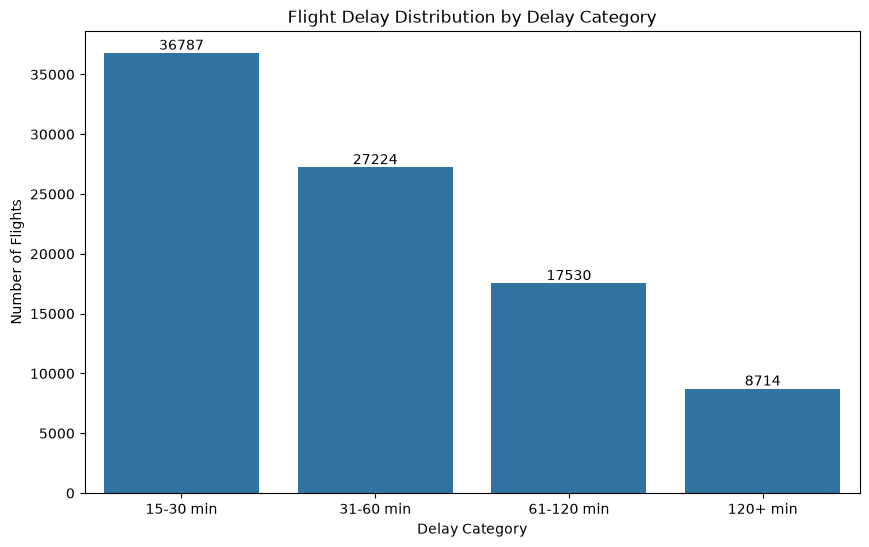

In [26]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=delay_distribution.index,
    y=delay_distribution.values
)

plt.title("Flight Delay Distribution by Delay Category")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

NameError: name 'month' is not defined

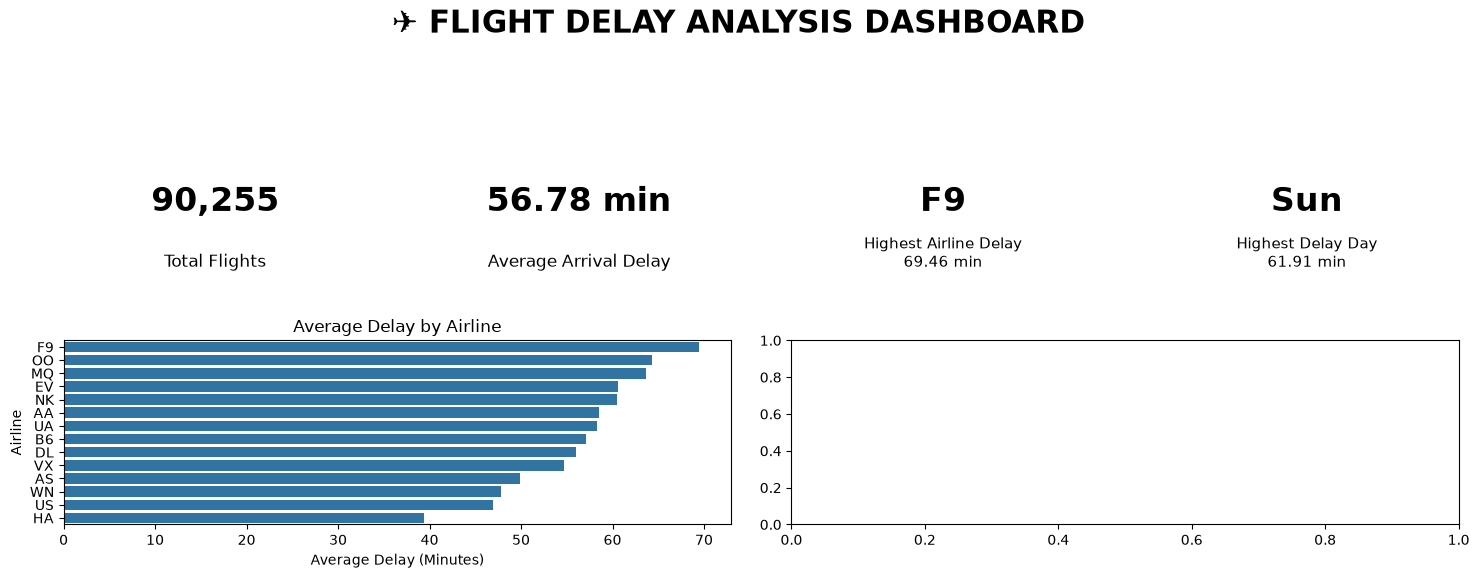

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("Flight_Analysis.csv")

# -----------------------------
# 2. Create Analysis Columns
# -----------------------------

# Delayed flight indicator
df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] >= 15).astype(int)

# Month names
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

day_names = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun"
}

# -----------------------------
# 3. Airline Analysis
# -----------------------------

airline_analysis = (
    df.groupby("AIRLINE")["ARRIVAL_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

# -----------------------------
# 4. Month Analysis
# -----------------------------

month_analysis = (
    df.groupby("MONTH")["ARRIVAL_DELAY"]
      .mean()
      .sort_index()
)

month_labels = [month_names[m] for m in month_analysis.index]

# -----------------------------
# 5. Airport Analysis
# Minimum 100 flights
# -----------------------------

airport_analysis = df.groupby("ORIGIN_AIRPORT").agg(
    Total_Flights=("ORIGIN_AIRPORT", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
)

airport_analysis = airport_analysis[
    airport_analysis["Total_Flights"] >= 100
].sort_values(
    "Average_Delay",
    ascending=False
)

top_airports = airport_analysis.head(10)

# -----------------------------
# 6. Day Analysis
# -----------------------------

day_analysis = (
    df.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"]
      .mean()
      .sort_index()
)

day_labels = [day_names[d] for d in day_analysis.index]

# -----------------------------
# 7. Important KPIs
# -----------------------------

total_flights = len(df)

average_delay = df["ARRIVAL_DELAY"].mean()

top_airline = airline_analysis.idxmax()

top_airline_delay = airline_analysis.max()

top_day_number = (
    df.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"]
      .mean()
      .idxmax()
)

top_day = day_names[top_day_number]

top_day_delay = day_analysis.max()

# -----------------------------
# 8. Dashboard
# -----------------------------

fig = plt.figure(figsize=(18, 11))

fig.suptitle(
    "✈ FLIGHT DELAY ANALYSIS DASHBOARD",
    fontsize=22,
    fontweight="bold"
)

# -----------------------------
# KPI 1
# -----------------------------

ax1 = plt.subplot2grid((4, 4), (0, 0))

ax1.text(
    0.5, 0.55,
    f"{total_flights:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax1.text(
    0.5, 0.20,
    "Total Flights",
    ha="center",
    fontsize=12
)

ax1.axis("off")

# -----------------------------
# KPI 2
# -----------------------------

ax2 = plt.subplot2grid((4, 4), (0, 1))

ax2.text(
    0.5, 0.55,
    f"{average_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax2.text(
    0.5, 0.20,
    "Average Arrival Delay",
    ha="center",
    fontsize=12
)

ax2.axis("off")

# -----------------------------
# KPI 3
# -----------------------------

ax3 = plt.subplot2grid((4, 4), (0, 2))

ax3.text(
    0.5, 0.55,
    top_airline,
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax3.text(
    0.5, 0.20,
    f"Highest Airline Delay\n{top_airline_delay:.2f} min",
    ha="center",
    fontsize=11
)

ax3.axis("off")

# -----------------------------
# KPI 4
# -----------------------------

ax4 = plt.subplot2grid((4, 4), (0, 3))

ax4.text(
    0.5, 0.55,
    top_day,
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax4.text(
    0.5, 0.20,
    f"Highest Delay Day\n{top_day_delay:.2f} min",
    ha="center",
    fontsize=11
)

ax4.axis("off")

# -----------------------------
# Airline Chart
# -----------------------------

ax5 = plt.subplot2grid((4, 4), (1, 0), colspan=2)

sns.barplot(
    x=airline_analysis.values,
    y=airline_analysis.index,
    ax=ax5
)

ax5.set_title("Average Delay by Airline")
ax5.set_xlabel("Average Delay (Minutes)")
ax5.set_ylabel("Airline")

# -----------------------------
# Month Chart
# -----------------------------

ax6 = plt.subplot2grid((4, 4), (1, 2), colspan=2)

ax = sns.barplot(
    x=month.index,
    y=month.values,
    ax=ax6
)

ax6.set_title("Average Delay by Month")
ax6.set_xlabel("Month")
ax6.set_ylabel("Delay (Minutes)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

# -----------------------------
# Airport Chart
# -----------------------------

ax7 = plt.subplot2grid((4, 4), (2, 0), colspan=2)

sns.barplot(
    x=top_airports["Average_Delay"],
    y=top_airports.index,
    ax=ax7
)

ax7.set_title("Top 10 Airports by Average Delay")
ax7.set_xlabel("Average Delay (Minutes)")
ax7.set_ylabel("Origin Airport")

# -----------------------------
# Day Chart
# -----------------------------

ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)

sns.barplot(
    x=day_labels,
    y=day_analysis.values,
    ax=ax8
)

ax8.set_title("Average Delay by Day")
ax8.set_xlabel("Day")
ax8.set_ylabel("Average Delay (Minutes)")

# -----------------------------
# Delay Distribution
# -----------------------------

ax9 = plt.subplot2grid((4, 4), (3, 0), colspan=4)

ax9.hist(
    df["ARRIVAL_DELAY"],
    bins=50
)

ax9.set_title("Distribution of Arrival Delays")
ax9.set_xlabel("Arrival Delay (Minutes)")
ax9.set_ylabel("Number of Flights")

plt.tight_layout(rect=[0, 0, 1, 0.99])

plt.show()


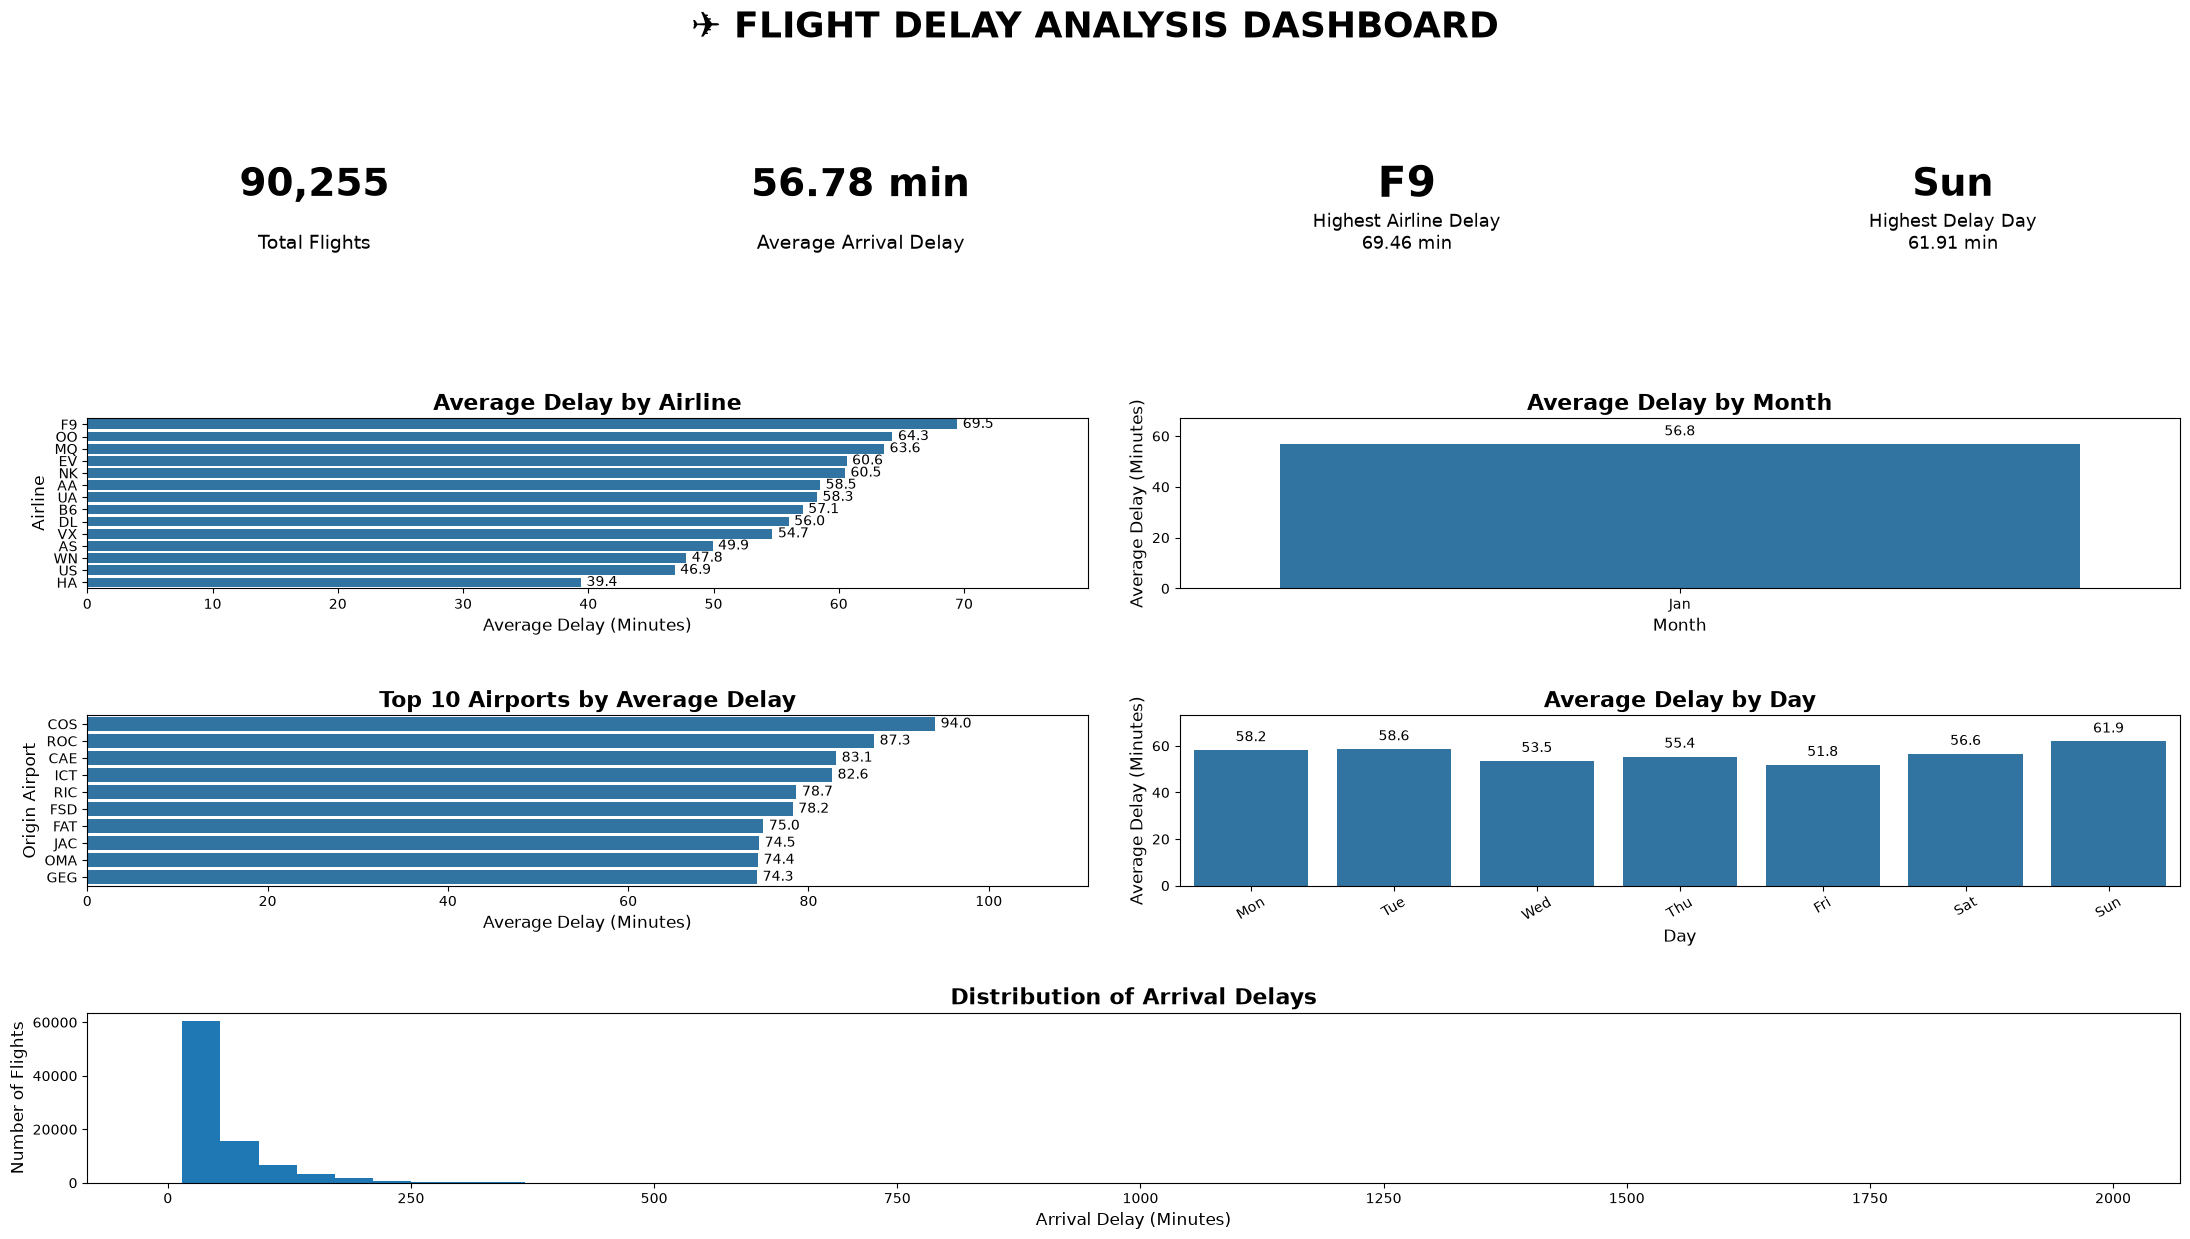

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv("Flight_Analysis.csv")

# -----------------------------
# 2. Create Analysis Columns
# -----------------------------

df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] >= 15).astype(int)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

day_names = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun"
}

# -----------------------------
# 3. Airline Analysis
# -----------------------------

airline_analysis = (
    df.groupby("AIRLINE")["ARRIVAL_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

# -----------------------------
# 4. Month Analysis
# -----------------------------

month_analysis = (
    df.groupby("MONTH")["ARRIVAL_DELAY"]
      .mean()
      .sort_index()
)

month_labels = [month_names[m] for m in month_analysis.index]

# -----------------------------
# 5. Airport Analysis
# Minimum 100 flights
# -----------------------------

airport_analysis = df.groupby("ORIGIN_AIRPORT").agg(
    Total_Flights=("ORIGIN_AIRPORT", "size"),
    Average_Delay=("ARRIVAL_DELAY", "mean")
)

airport_analysis = airport_analysis[
    airport_analysis["Total_Flights"] >= 100
].sort_values(
    "Average_Delay",
    ascending=False
)

top_airports = airport_analysis.head(10)

# -----------------------------
# 6. Day Analysis
# -----------------------------

day_analysis = (
    df.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"]
      .mean()
      .sort_index()
)

day_labels = [day_names[d] for d in day_analysis.index]

# -----------------------------
# 7. Important KPIs
# -----------------------------

total_flights = len(df)

average_delay = df["ARRIVAL_DELAY"].mean()

top_airline = airline_analysis.idxmax()
top_airline_delay = airline_analysis.max()

top_day_number = (
    df.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"]
      .mean()
      .idxmax()
)

top_day = day_names[top_day_number]
top_day_delay = day_analysis.max()

# -----------------------------
# 8. Dashboard
# -----------------------------

# Increased dashboard size
fig = plt.figure(figsize=(22, 15))

fig.suptitle(
    "✈ FLIGHT DELAY ANALYSIS DASHBOARD",
    fontsize=26,
    fontweight="bold",
    y=0.99
)

# ============================================================
# KPI 1
# ============================================================

ax1 = plt.subplot2grid((5, 4), (0, 0))

ax1.text(
    0.5, 0.62,
    f"{total_flights:,}",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold"
)

ax1.text(
    0.5, 0.25,
    "Total Flights",
    ha="center",
    fontsize=14
)

ax1.set_facecolor("whitesmoke")
ax1.axis("off")

# ============================================================
# KPI 2
# ============================================================

ax2 = plt.subplot2grid((5, 4), (0, 1))

ax2.text(
    0.5, 0.62,
    f"{average_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold"
)

ax2.text(
    0.5, 0.25,
    "Average Arrival Delay",
    ha="center",
    fontsize=14
)

ax2.set_facecolor("whitesmoke")
ax2.axis("off")

# ============================================================
# KPI 3
# ============================================================

ax3 = plt.subplot2grid((5, 4), (0, 2))

ax3.text(
    0.5, 0.62,
    top_airline,
    ha="center",
    va="center",
    fontsize=30,
    fontweight="bold"
)

ax3.text(
    0.5, 0.25,
    f"Highest Airline Delay\n{top_airline_delay:.2f} min",
    ha="center",
    fontsize=13
)

ax3.set_facecolor("whitesmoke")
ax3.axis("off")

# ============================================================
# KPI 4
# ============================================================

ax4 = plt.subplot2grid((5, 4), (0, 3))

ax4.text(
    0.5, 0.62,
    top_day,
    ha="center",
    va="center",
    fontsize=27,
    fontweight="bold"
)

ax4.text(
    0.5, 0.25,
    f"Highest Delay Day\n{top_day_delay:.2f} min",
    ha="center",
    fontsize=13
)

ax4.set_facecolor("whitesmoke")
ax4.axis("off")

# ============================================================
# AIRLINE CHART
# ============================================================

ax5 = plt.subplot2grid((5, 4), (1, 0), colspan=2)

ax = sns.barplot(
    x=airline_analysis.values,
    y=airline_analysis.index,
    ax=ax5
)

ax5.set_title(
    "Average Delay by Airline",
    fontsize=16,
    fontweight="bold"
)

ax5.set_xlabel("Average Delay (Minutes)", fontsize=12)
ax5.set_ylabel("Airline", fontsize=12)

# Add numbers to horizontal bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4,
        fontsize=10
    )

# Give extra space for numbers
ax5.set_xlim(
    0,
    airline_analysis.max() * 1.15
)

# ============================================================
# MONTH CHART
# ============================================================

ax6 = plt.subplot2grid((5, 4), (1, 2), colspan=2)

ax = sns.barplot(
    x=month_labels,
    y=month_analysis.values,
    ax=ax6
)

ax6.set_title(
    "Average Delay by Month",
    fontsize=16,
    fontweight="bold"
)

ax6.set_xlabel("Month", fontsize=12)
ax6.set_ylabel("Average Delay (Minutes)", fontsize=12)

# Add numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4,
        fontsize=10
    )

# Give space above bars
ax6.set_ylim(
    0,
    month_analysis.max() * 1.18
)

# ============================================================
# AIRPORT CHART
# ============================================================

ax7 = plt.subplot2grid((5, 4), (2, 0), colspan=2)

ax = sns.barplot(
    x=top_airports["Average_Delay"],
    y=top_airports.index,
    ax=ax7
)

ax7.set_title(
    "Top 10 Airports by Average Delay",
    fontsize=16,
    fontweight="bold"
)

ax7.set_xlabel("Average Delay (Minutes)", fontsize=12)
ax7.set_ylabel("Origin Airport", fontsize=12)

# Add numbers to horizontal bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4,
        fontsize=10
    )

# Extra space for numbers
ax7.set_xlim(
    0,
    top_airports["Average_Delay"].max() * 1.18
)

# ============================================================
# DAY CHART
# ============================================================

ax8 = plt.subplot2grid((5, 4), (2, 2), colspan=2)

ax = sns.barplot(
    x=day_labels,
    y=day_analysis.values,
    ax=ax8
)

ax8.set_title(
    "Average Delay by Day",
    fontsize=16,
    fontweight="bold"
)

ax8.set_xlabel("Day", fontsize=12)
ax8.set_ylabel("Average Delay (Minutes)", fontsize=12)

ax8.tick_params(
    axis="x",
    rotation=30
)

# Add numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=4,
        fontsize=10
    )

# Extra space for numbers
ax8.set_ylim(
    0,
    day_analysis.max() * 1.18
)

# ============================================================
# DELAY DISTRIBUTION
# ============================================================

ax9 = plt.subplot2grid((5, 4), (3, 0), colspan=4)

ax9.hist(
    df["ARRIVAL_DELAY"],
    bins=50
)

ax9.set_title(
    "Distribution of Arrival Delays",
    fontsize=16,
    fontweight="bold"
)

ax9.set_xlabel(
    "Arrival Delay (Minutes)",
    fontsize=12
)

ax9.set_ylabel(
    "Number of Flights",
    fontsize=12
)

# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96],
    h_pad=3,
    w_pad=3
)

plt.show()

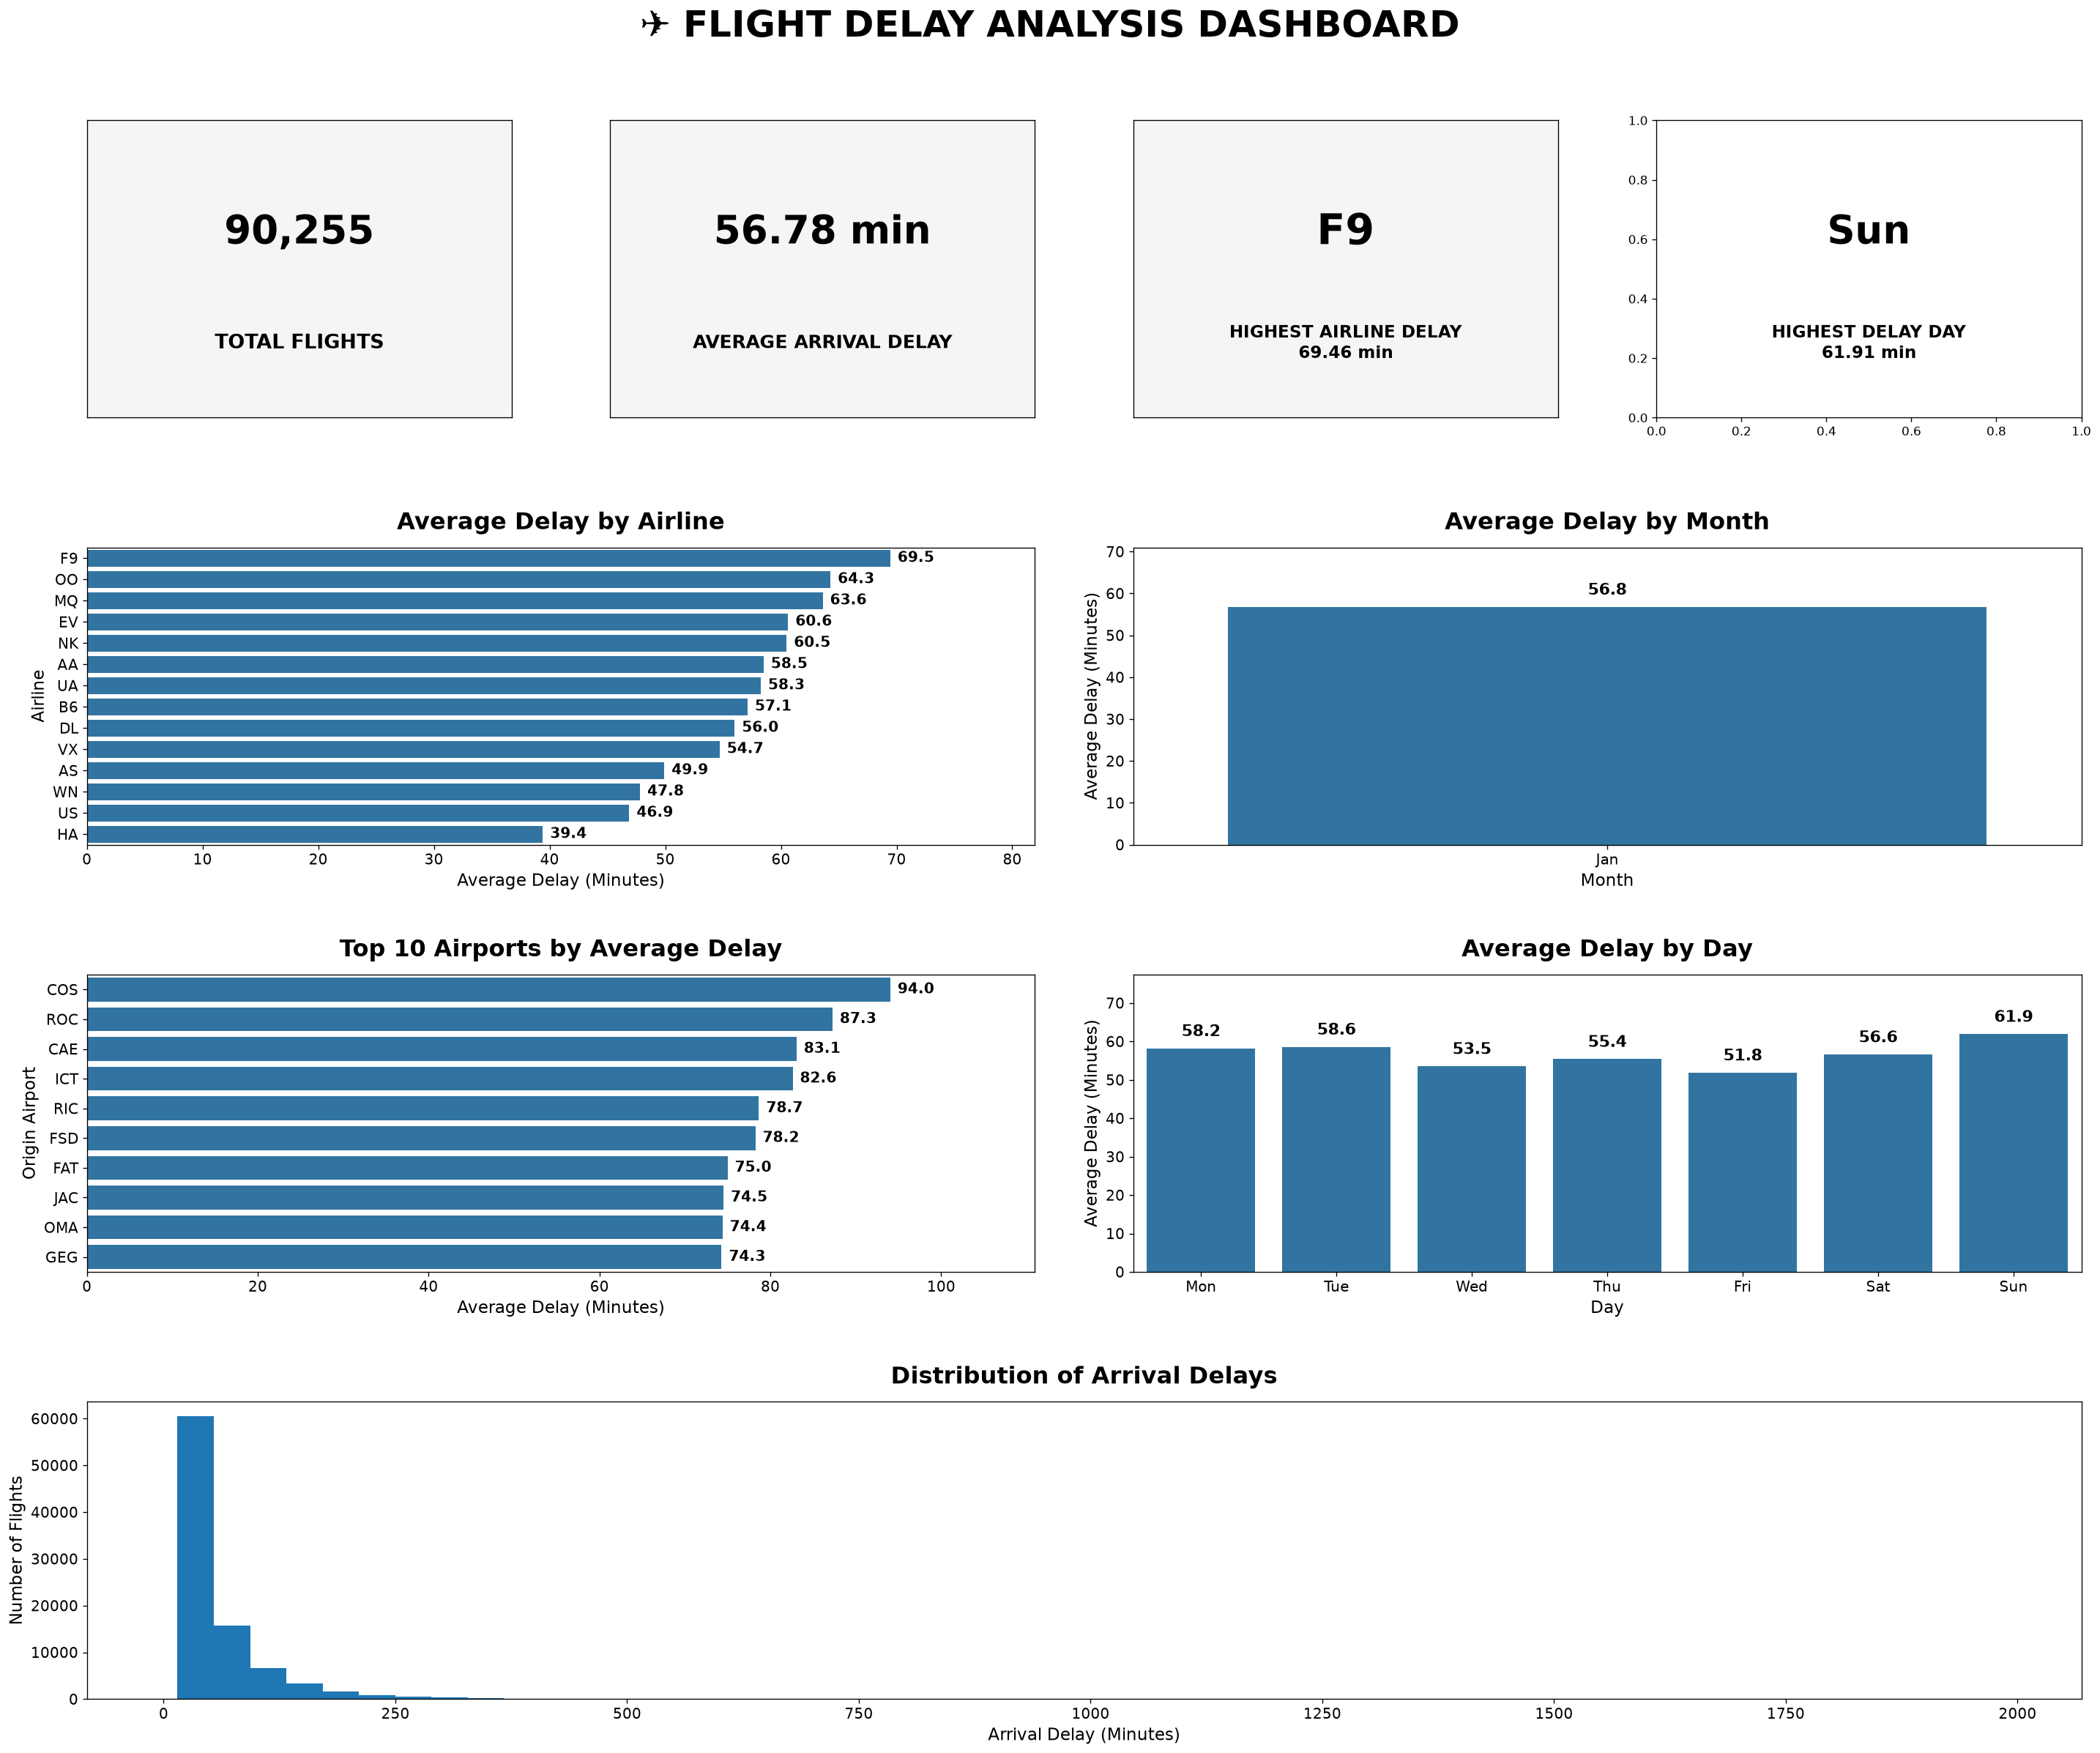

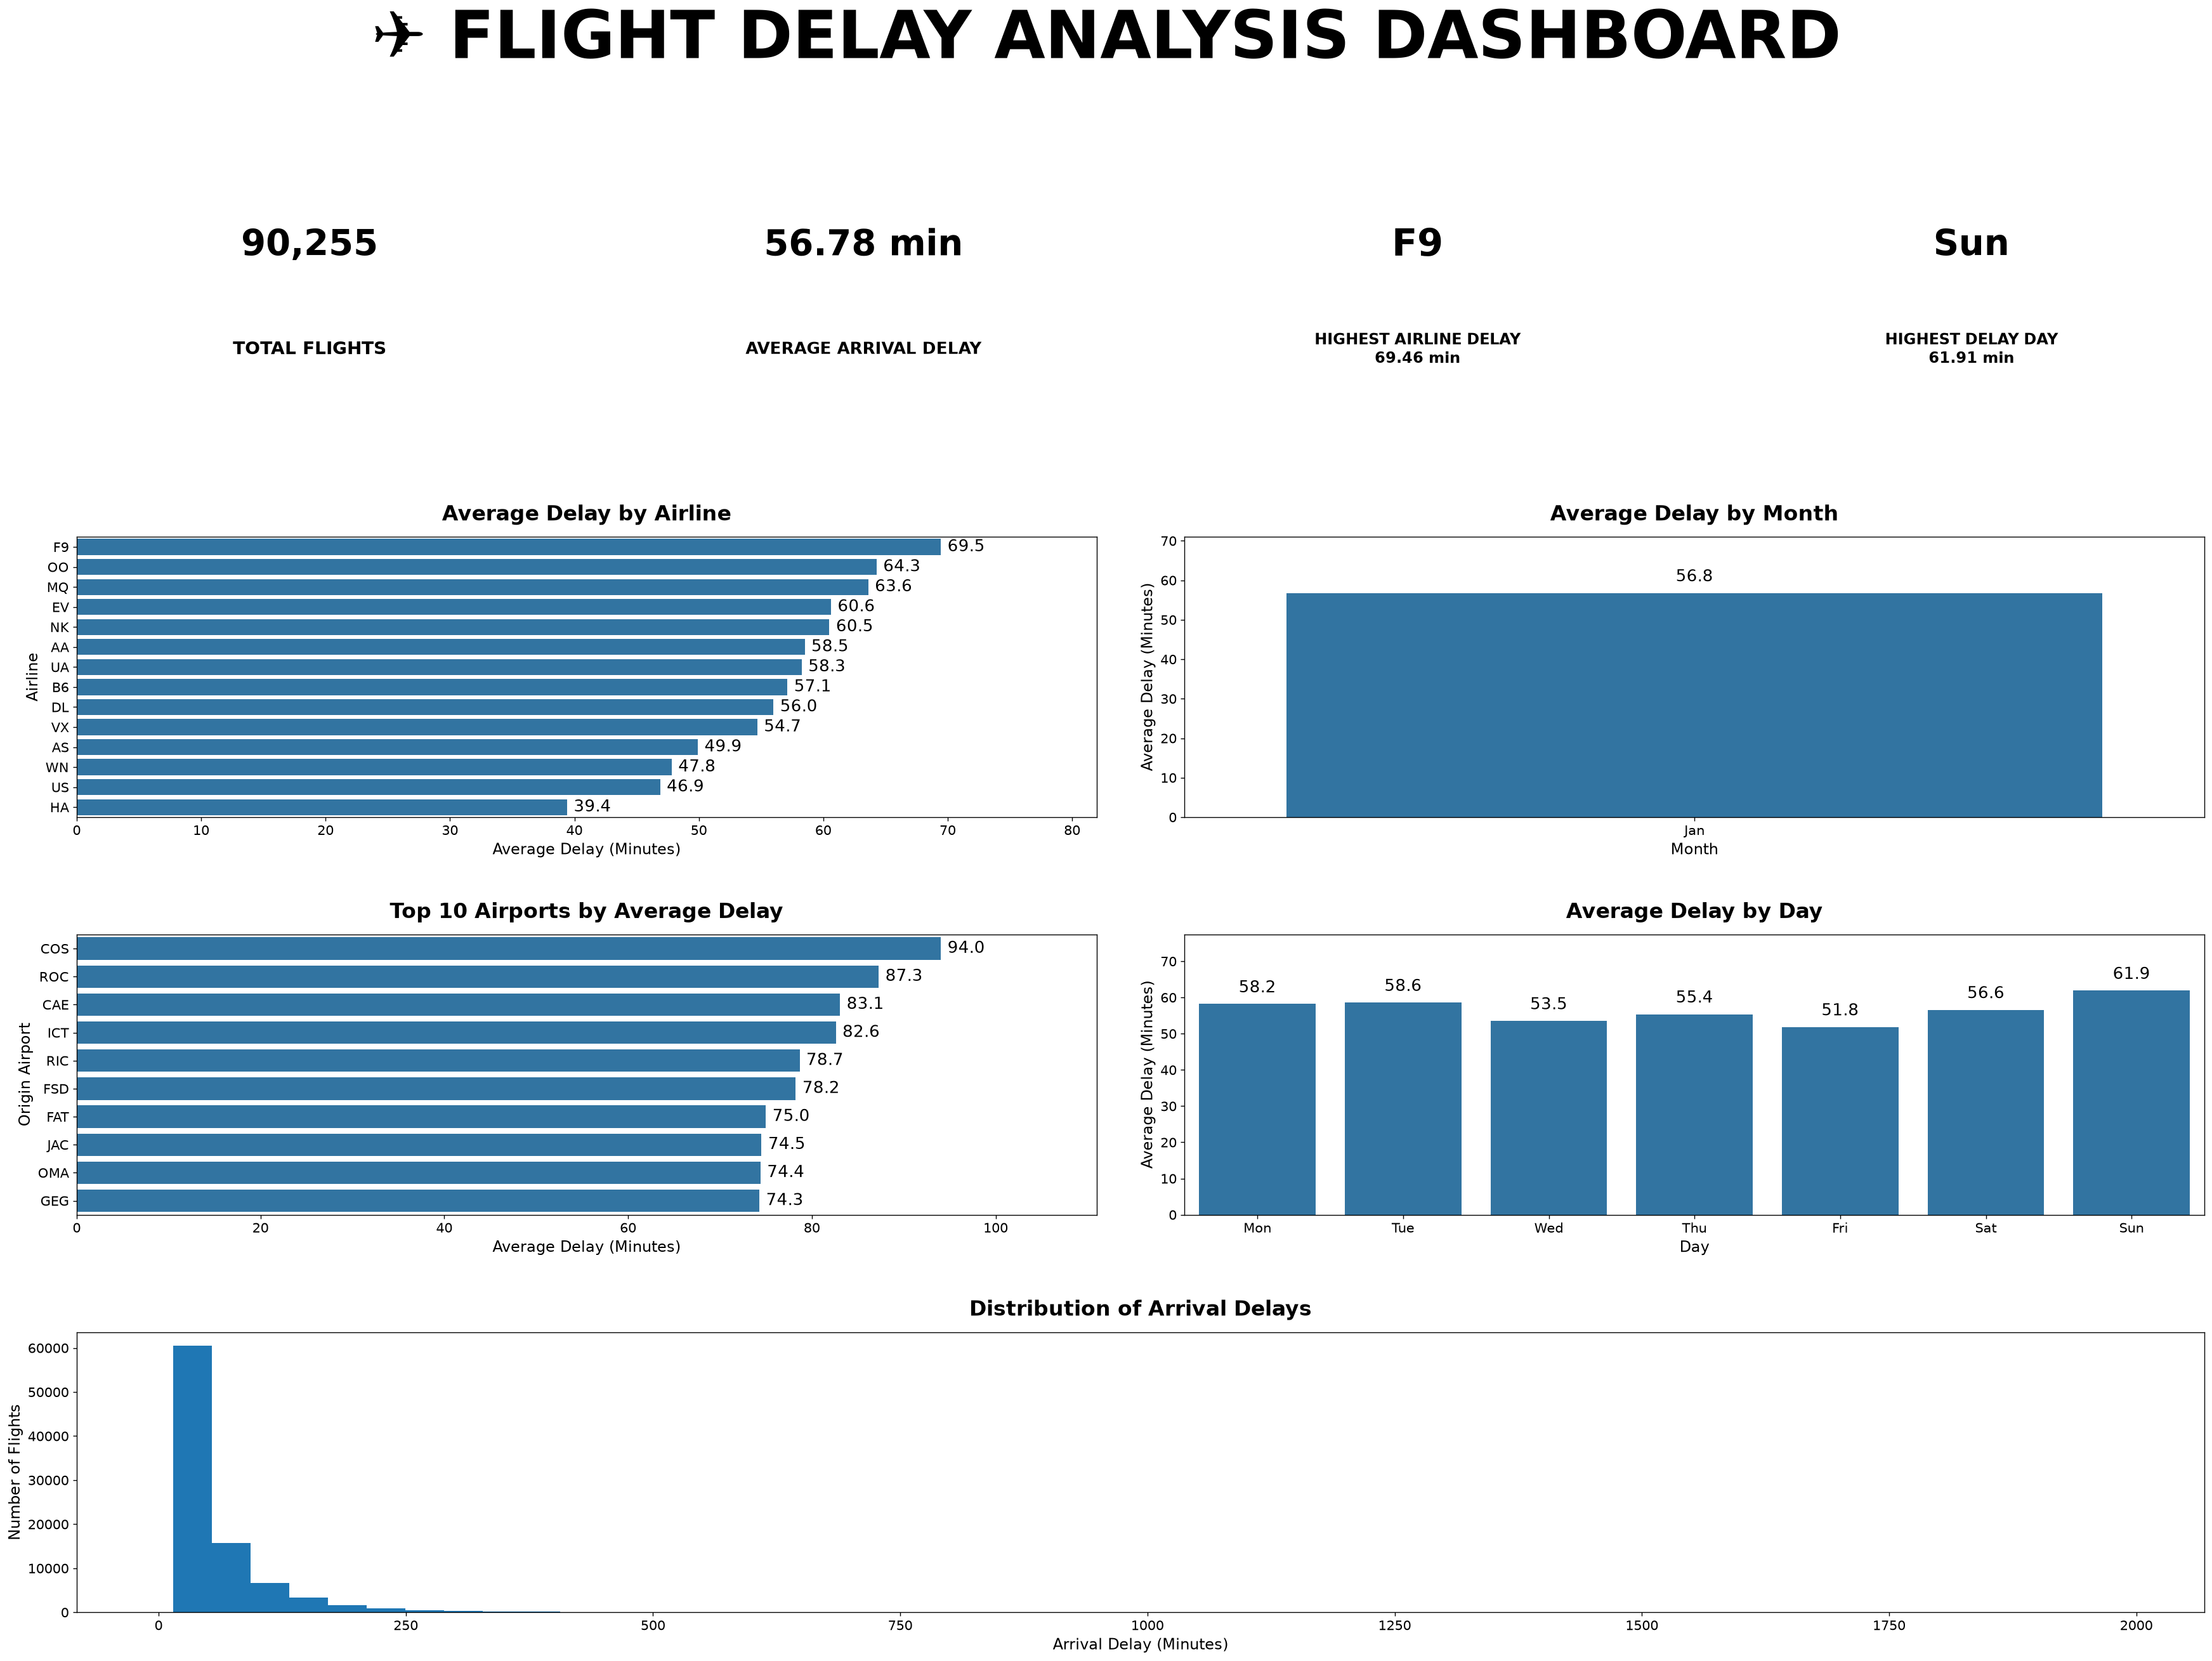

In [31]:
# ============================================================
# 8. LARGE FLIGHT DELAY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(28, 21), dpi=125)

fig.suptitle(
    "✈ FLIGHT DELAY ANALYSIS DASHBOARD",
    fontsize=60,
    fontweight="bold",
    y=0.995
)


# -----------------------------
# KPI 1 - Total Flights
# -----------------------------

ax1 = plt.subplot2grid((4, 4), (0, 0))

ax1.text(
    0.5, 0.62,
    f"{total_flights:,}",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax1.text(
    0.5, 0.25,
    "TOTAL FLIGHTS",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)
ax1.axis("off")

# -----------------------------
# KPI 2 - Average Delay
# -----------------------------

ax2 = plt.subplot2grid((4, 4), (0, 1))

ax2.text(
    0.5, 0.62,
    f"{average_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax2.text(
    0.5, 0.25,
    "AVERAGE ARRIVAL DELAY",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax2.axis("off")

# -----------------------------
# KPI 3 - Airline
# -----------------------------

ax3 = plt.subplot2grid((4, 4), (0, 2))

ax3.text(
    0.5, 0.62,
    top_airline,
    ha="center",
    va="center",
    fontsize=34,
    fontweight="bold"
)

ax3.text(
    0.5, 0.25,
    f"HIGHEST AIRLINE DELAY\n{top_airline_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax3.axis("off")

# -----------------------------
# KPI 4 - Day
# -----------------------------

ax4 = plt.subplot2grid((4, 4), (0, 3))

ax4.text(
    0.5, 0.62,
    top_day,
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax4.text(
    0.5, 0.25,
    f"HIGHEST DELAY DAY\n{top_day_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax4.axis("off")

# ============================================================
# AIRLINE CHART
# ============================================================

ax5 = plt.subplot2grid((4, 4), (1, 0), colspan=2)

ax = sns.barplot(
    x=airline_analysis.values,
    y=airline_analysis.index,
    ax=ax5
)

ax5.set_title(
    "Average Delay by Airline",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax5.set_xlabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax5.set_ylabel(
    "Airline",
    fontsize=14
)

# Larger airline labels
ax5.tick_params(
    axis="both",
    labelsize=12
)

# Numbers on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=6,
        fontsize=15,
    )

# Extra space for numbers
ax5.set_xlim(
    0,
    airline_analysis.max() * 1.18
)


# ============================================================
# MONTH CHART
# ============================================================

ax6 = plt.subplot2grid((4, 4), (1, 2), colspan=2)

ax = sns.barplot(
    x=month_labels,
    y=month_analysis.values,
    ax=ax6
)

ax6.set_title(
    "Average Delay by Month",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax6.set_xlabel(
    "Month",
    fontsize=14
)

ax6.set_ylabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax6.tick_params(
    axis="both",
    labelsize=12
)

# Numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=7,
        fontsize=15,
    )

ax6.set_ylim(
    0,
    month_analysis.max() * 1.25
)


# ============================================================
# AIRPORT CHART
# ============================================================

ax7 = plt.subplot2grid((4, 4), (2, 0), colspan=2)

ax = sns.barplot(
    x=top_airports["Average_Delay"],
    y=top_airports.index,
    ax=ax7
)

ax7.set_title(
    "Top 10 Airports by Average Delay",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax7.set_xlabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax7.set_ylabel(
    "Origin Airport",
    fontsize=14
)

ax7.tick_params(
    axis="both",
    labelsize=12
)

# Numbers at end of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=6,
        fontsize=15,
    )

ax7.set_xlim(
    0,
    top_airports["Average_Delay"].max() * 1.18
)


# ============================================================
# DAY CHART
# ============================================================

ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)

ax = sns.barplot(
    x=day_labels,
    y=day_analysis.values,
    ax=ax8
)

ax8.set_title(
    "Average Delay by Day",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax8.set_xlabel(
    "Day",
    fontsize=14
)

ax8.set_ylabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax8.tick_params(
    axis="both",
    labelsize=12
)

ax8.tick_params(
    axis="x",
    rotation=0
)

# Numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=7,
        fontsize=15,
    )

ax8.set_ylim(
    0,
    day_analysis.max() * 1.25
)


# ============================================================
# DELAY DISTRIBUTION
# ============================================================

ax9 = plt.subplot2grid((4, 4), (3, 0), colspan=4)

ax9.hist(
    df["ARRIVAL_DELAY"],
    bins=50
)

ax9.set_title(
    "Distribution of Arrival Delays",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax9.set_xlabel(
    "Arrival Delay (Minutes)",
    fontsize=14
)

ax9.set_ylabel(
    "Number of Flights",
    fontsize=14
)

ax9.tick_params(
    axis="both",
    labelsize=12
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.97],
    h_pad=4,
    w_pad=4
)

plt.show()

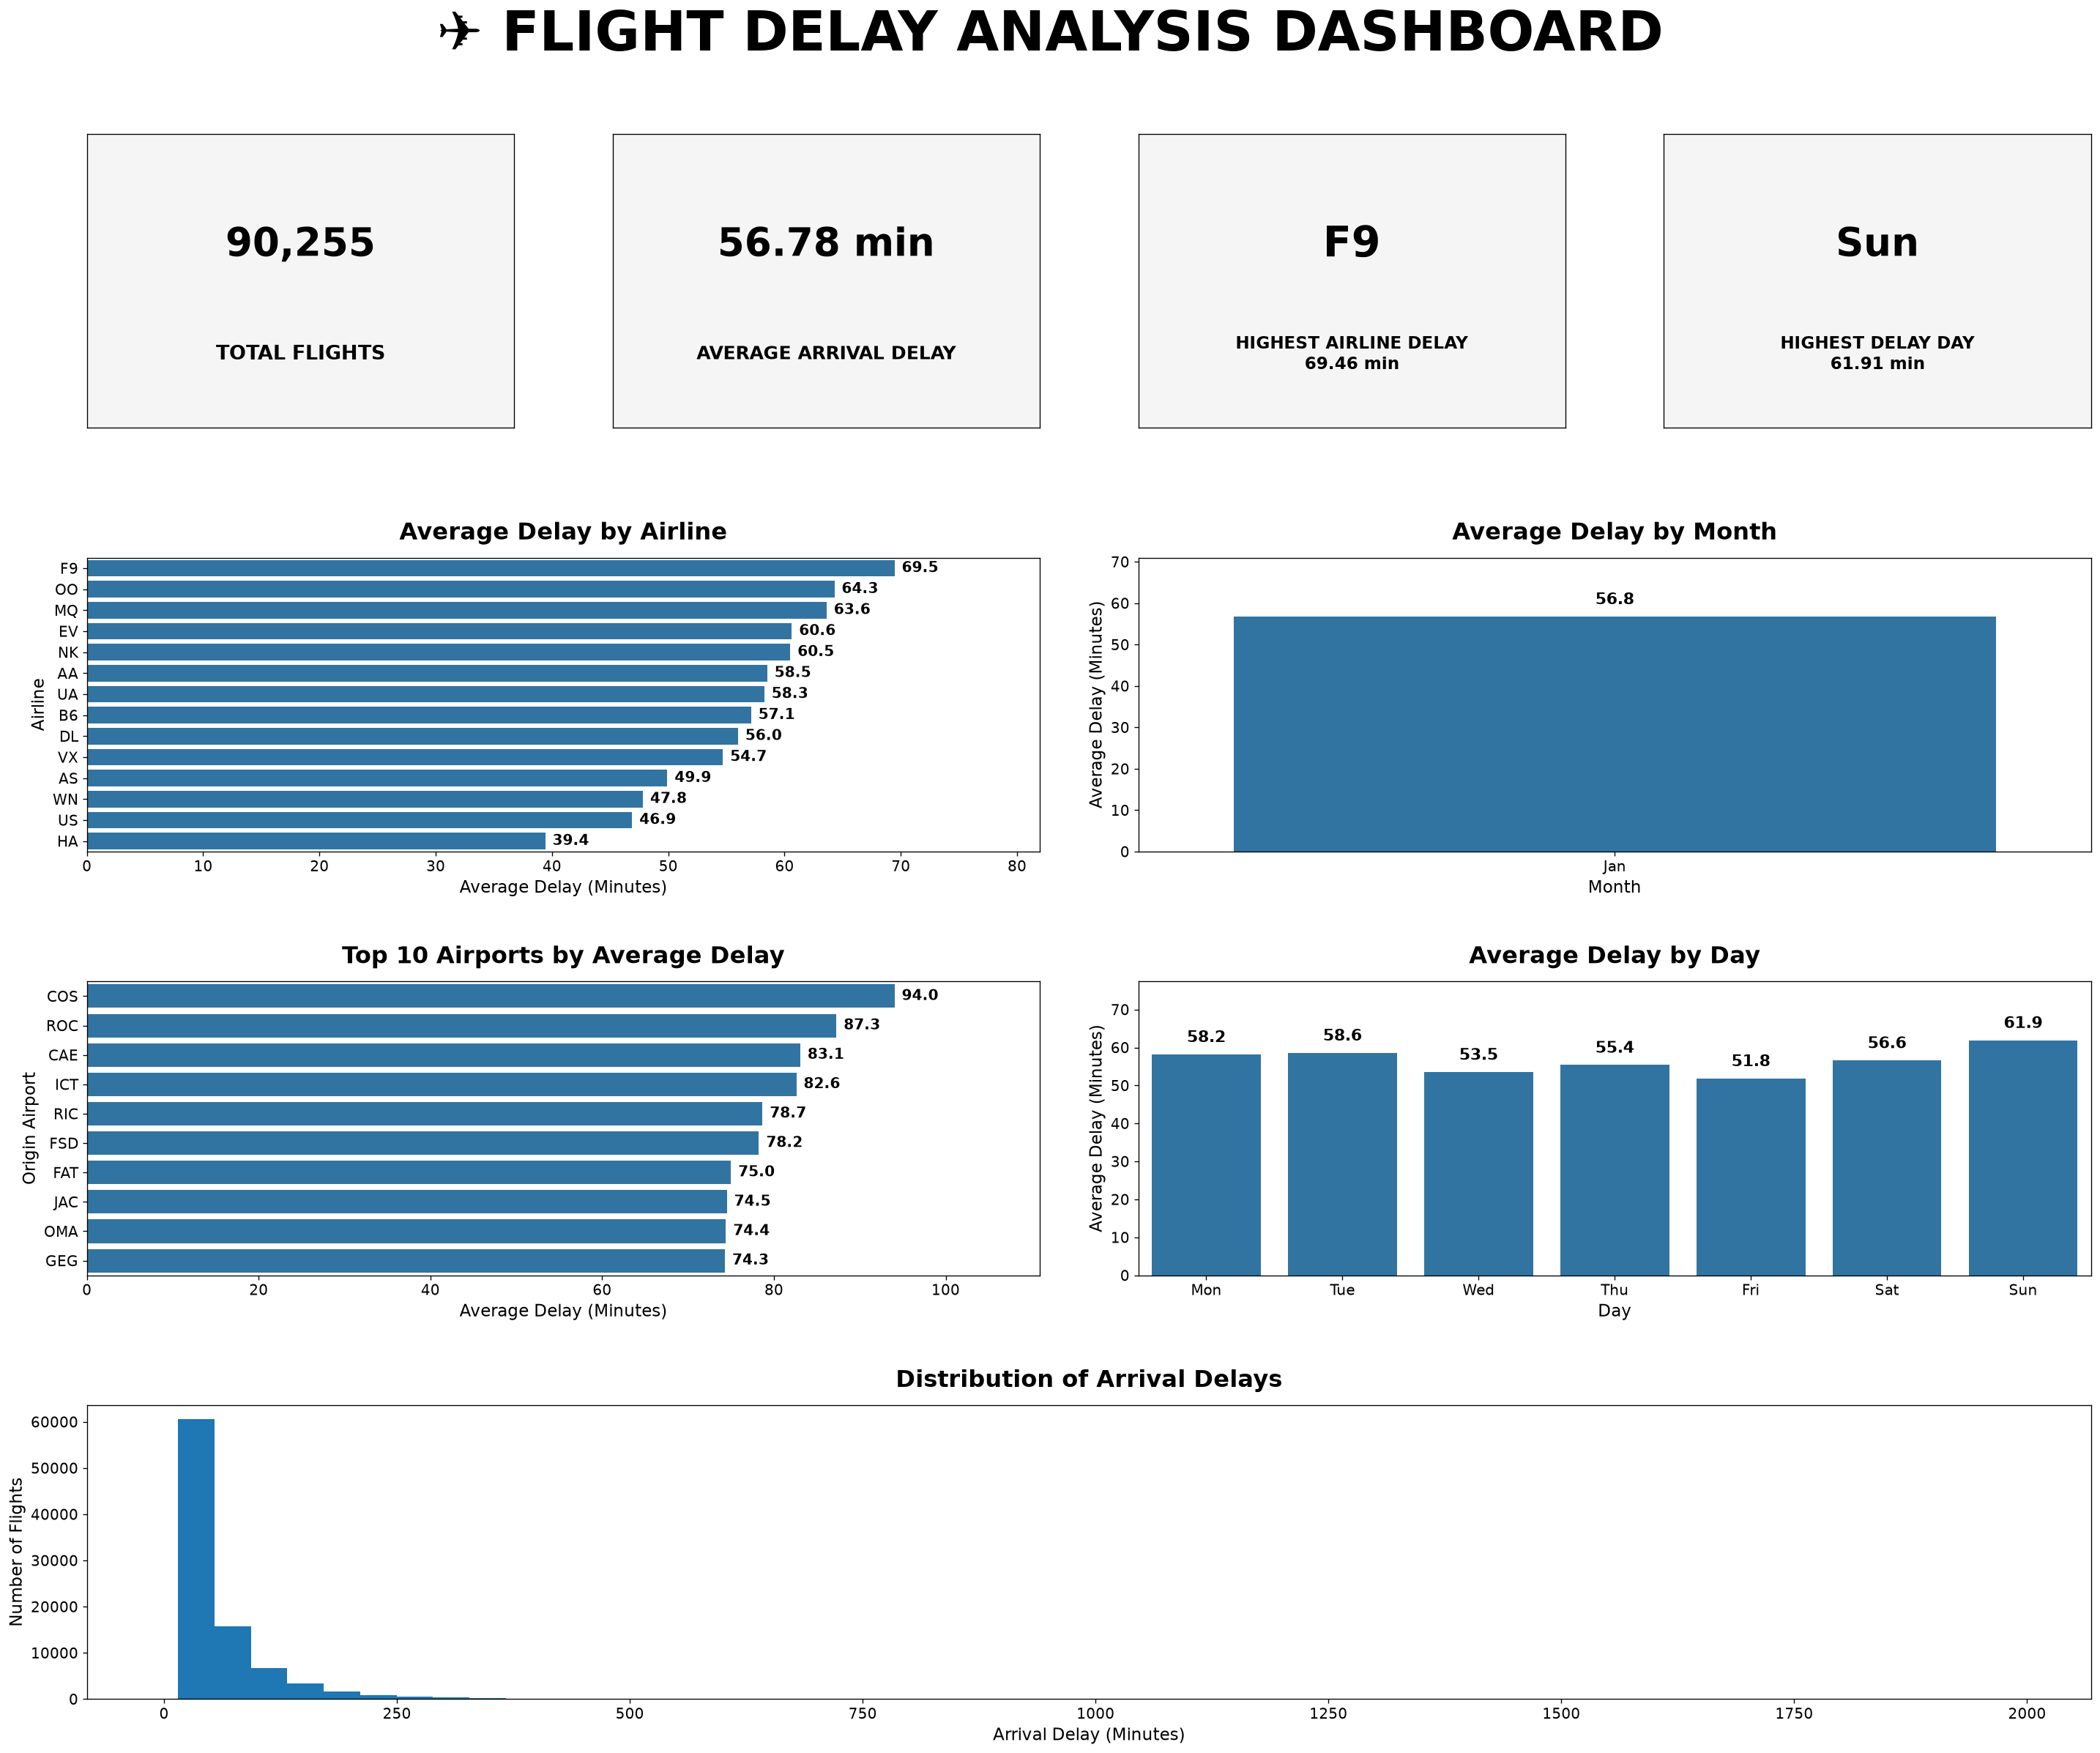

In [33]:
# ============================================================
# 8. LARGE FLIGHT DELAY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(24, 20), dpi=120)

fig.suptitle(
    "✈ FLIGHT DELAY ANALYSIS DASHBOARD",
    fontsize=45,
    fontweight="bold",
    y=0.995
)

# ============================================================
# KPI BOXES
# ============================================================

# -----------------------------
# KPI 1 - Total Flights
# -----------------------------

ax1 = plt.subplot2grid((4, 4), (0, 0))

ax1.text(
    0.5, 0.62,
    f"{total_flights:,}",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax1.text(
    0.5, 0.25,
    "TOTAL FLIGHTS",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax1.set_facecolor("whitesmoke")
ax1.set_xticks([])
ax1.set_yticks([])

# -----------------------------
# KPI 2 - Average Delay
# -----------------------------

ax2 = plt.subplot2grid((4, 4), (0, 1))

ax2.text(
    0.5, 0.62,
    f"{average_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax2.text(
    0.5, 0.25,
    "AVERAGE ARRIVAL DELAY",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

ax2.set_facecolor("whitesmoke")
ax2.set_xticks([])
ax2.set_yticks([])

# -----------------------------
# KPI 3 - Airline
# -----------------------------

ax3 = plt.subplot2grid((4, 4), (0, 2))

ax3.text(
    0.5, 0.62,
    top_airline,
    ha="center",
    va="center",
    fontsize=34,
    fontweight="bold"
)

ax3.text(
    0.5, 0.25,
    f"HIGHEST AIRLINE DELAY\n{top_airline_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax3.set_facecolor("whitesmoke")
ax3.set_xticks([])
ax3.set_yticks([])

# -----------------------------
# KPI 4 - Day
# -----------------------------

ax4 = plt.subplot2grid((4, 4), (0, 3))

ax4.text(
    0.5, 0.62,
    top_day,
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

ax4.text(
    0.5, 0.25,
    f"HIGHEST DELAY DAY\n{top_day_delay:.2f} min",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax4.set_facecolor("whitesmoke")
ax4.set_xticks([])
ax4.set_yticks([])


# ============================================================
# AIRLINE CHART
# ============================================================

ax5 = plt.subplot2grid((4, 4), (1, 0), colspan=2)

ax = sns.barplot(
    x=airline_analysis.values,
    y=airline_analysis.index,
    ax=ax5
)

ax5.set_title(
    "Average Delay by Airline",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax5.set_xlabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax5.set_ylabel(
    "Airline",
    fontsize=14
)

# Larger airline labels
ax5.tick_params(
    axis="both",
    labelsize=12
)

# Numbers on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=6,
        fontsize=12,
        fontweight="bold"
    )

# Extra space for numbers
ax5.set_xlim(
    0,
    airline_analysis.max() * 1.18
)


# ============================================================
# MONTH CHART
# ============================================================

ax6 = plt.subplot2grid((4, 4), (1, 2), colspan=2)

ax = sns.barplot(
    x=month_labels,
    y=month_analysis.values,
    ax=ax6
)

ax6.set_title(
    "Average Delay by Month",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax6.set_xlabel(
    "Month",
    fontsize=14
)

ax6.set_ylabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax6.tick_params(
    axis="both",
    labelsize=12
)

# Numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=7,
        fontsize=13,
        fontweight="bold"
    )

ax6.set_ylim(
    0,
    month_analysis.max() * 1.25
)


# ============================================================
# AIRPORT CHART
# ============================================================

ax7 = plt.subplot2grid((4, 4), (2, 0), colspan=2)

ax = sns.barplot(
    x=top_airports["Average_Delay"],
    y=top_airports.index,
    ax=ax7
)

ax7.set_title(
    "Top 10 Airports by Average Delay",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax7.set_xlabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax7.set_ylabel(
    "Origin Airport",
    fontsize=14
)

ax7.tick_params(
    axis="both",
    labelsize=12
)

# Numbers at end of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=6,
        fontsize=12,
        fontweight="bold"
    )

ax7.set_xlim(
    0,
    top_airports["Average_Delay"].max() * 1.18
)


# ============================================================
# DAY CHART
# ============================================================

ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)

ax = sns.barplot(
    x=day_labels,
    y=day_analysis.values,
    ax=ax8
)

ax8.set_title(
    "Average Delay by Day",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax8.set_xlabel(
    "Day",
    fontsize=14
)

ax8.set_ylabel(
    "Average Delay (Minutes)",
    fontsize=14
)

ax8.tick_params(
    axis="both",
    labelsize=12
)

ax8.tick_params(
    axis="x",
    rotation=0
)

# Numbers above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=7,
        fontsize=13,
        fontweight="bold"
    )

ax8.set_ylim(
    0,
    day_analysis.max() * 1.25
)


# ============================================================
# DELAY DISTRIBUTION
# ============================================================

ax9 = plt.subplot2grid((4, 4), (3, 0), colspan=4)

ax9.hist(
    df["ARRIVAL_DELAY"],
    bins=50
)

ax9.set_title(
    "Distribution of Arrival Delays",
    fontsize=19,
    fontweight="bold",
    pad=15
)

ax9.set_xlabel(
    "Arrival Delay (Minutes)",
    fontsize=14
)

ax9.set_ylabel(
    "Number of Flights",
    fontsize=14
)

ax9.tick_params(
    axis="both",
    labelsize=12
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.97],
    h_pad=4,
    w_pad=4
)

plt.show()